# Métodos de agrupamiento

En este ejercicio, aplicaremos los conceptos vistos en clase referentes a métodos de agrupamiento no supervisados. Específicamente, explorarás el uso de KMeans y DBScan usando la librería de scikit-learn. En la primera sección analizaremos K-means y en la segunda DBScan


## 1. K-means

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN, KMeans
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
random_state = 0 # Fijamos la semilla aleatoria para que siempre den los mismos datos
np.random.seed(random_state)
# Podemos establecer los colores con los que se graficará con matplotlib
# utilizando un cmap distinto
matplotlib.rc('image', cmap='nipy_spectral')

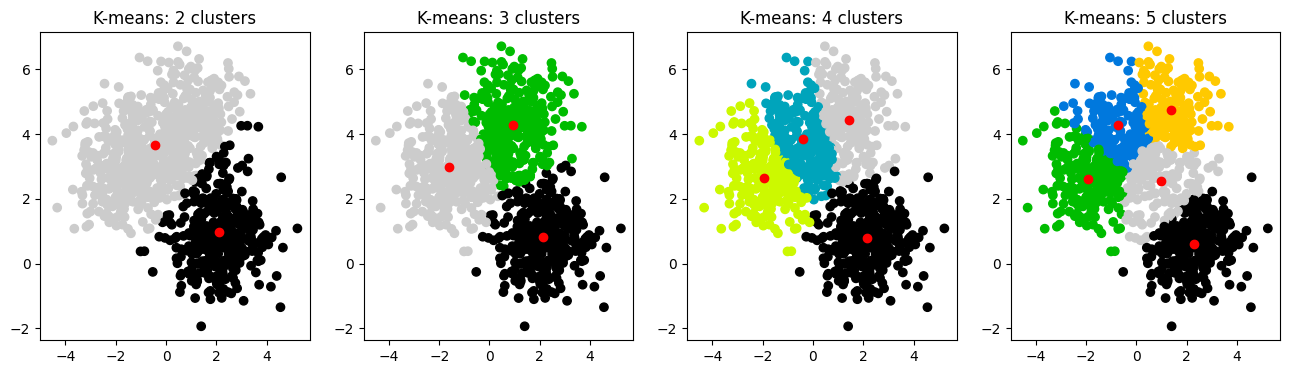

In [15]:
# Generaremos 3 blobs, cada uno con datos iguales. En total habran 1000 puntos distribuidos en estos blobs.
n_samples = 1000
X, _ = datasets.make_blobs(n_samples=n_samples, centers=3, random_state=random_state)

# Utilizaremos el algoritmo de KMeans para encontrar clusters en los datos
n_cols = 4
n_clusters_list = [2, 3, 4, 5]
rows = len(n_clusters_list) // n_cols
fig, axes = plt.subplots(rows, n_cols, figsize=(4*n_cols, 4))
axes = axes.flatten()
for ax, n_clusters in zip(axes, n_clusters_list):
    # TODO: Encuentra los clusters utilizando el algoritmo de KMeans implementado en scikit-learn
    # ====== Start of solution =====
    model = KMeans(n_clusters=n_clusters, random_state=random_state)
    model.fit(X)

    # TODO: Grafica los datos usando scatter, recuerda que X = (x, y)
    x = X[:,0]
    y = X[:,1]
    ax.scatter(x, y, c=model.labels_, cmap='nipy_spectral')
    # TODO: Lee la documentación de sklearn para obtener los centroides del modelo entrenado
    # y grafícalos con ax.scatter
    centroids = model.cluster_centers_
    xx = centroids[:,0]
    yy = centroids[:,1]
    ax.scatter(xx,yy,c = 'red')
    ax.set_title(f"K-means: {n_clusters} clusters")
plt.show()

En la sección anterior utilizamos 2, 3, 4 y 5 clusters para encontar patrones en los datos y los resultados se graficaron.

TODO: Contesta la siguiente pregunta

- ¿Cúal propuesta de clusters consideras la mejor y porqué? El 3 clústers, por que el espació se dividió una manera muy equitativa y también cada cluster abarca un grupo claro de datos sin partirlos demasiado. Por ejemplo, en el de 5 clústers también se ve que se dividió muy equitativamente, pero el "espacio" que abarcan los clústers es más pequeño que en el caso de 3 clústers.

## 1.2 Definiendo métricas de evaluación

En el algoritmo de K-means debemos seleccionar la cantidad de clusters para poder hacer fit al modelo. Para decidir cuantos clusters utilizar podemos evaluar visualmente o hacer un análisis cuantitativo. 

Una estrategia común para realizar el análisis consiste en entrenar modelos con multiples propuestas de k-grupos y seleccionar la propuesta con el mejor rendimiento. Para ello se debe utilizar una métrica que evalúe el desempeño del algoritmo.

El ["silhouette score"](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) es una métrica muy útil para este objetivo que consiste en medir la distancia intra-grupo e inter-grupo. Esta métrica considera como buen grupo a aquel que tiene una pequeña distancia promedio intra-grupo y que se encuentra muy separado de los demas grupos. Un acomodo con buenos grupos tendrá un silhoute score cercano a 1 y una mala selección de grupos tendrá un score cercano -1. 

En la siguiente sección seguiremos esta estrategia para determinar la mejor cantidad de grupos en los datos provistos.

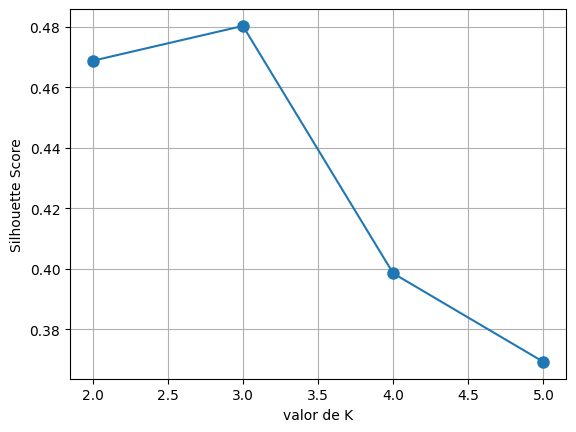

In [17]:
from sklearn.metrics import silhouette_score

Ks = range(2,6)
scores = []
for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X)
    # TODO: Obten el silhouete score de nuestro modelo
    # ====== Start of solution =====
    score = silhouette_score(X, kmeans.labels_)
    # ====== End of solution =====
    scores.append(score)

plt.plot(Ks,scores,'-o', markersize=8)
plt.xlabel("valor de K")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

### TODO: Contesta la siguiente pregunta

De acuerdo al silhouete score
- ¿Qué sería mejor, elegir 4 o 5 clusters? 4 clústers.
- ¿Cuántos clusters se deberían utilizar para entrenar el algoritmo? ¿Concuerda con tu selección realizada tras visualizar los datos? Se deberían de elergir 3 clústers. Sí concuerda con nuestra selección realizada tras visualizar los datos. Porchas decía que 5 clústers que porque más variedad pero nel, ya veníamos intuyendo Derek y yo que sería mejor la 3 porque divide bien el espacio y cada clúster tiene un "buen" espacio.

## 1.3 Rompiendo las asunciones de K-Means

K-means es un algoritmo que funciona en base a algunas asunciones que pueden no siempre ser ciertas, en esta seccion analizaremos algunos casos en los cuales el K-means puede que no genere la solución esperada.

In [18]:
n_samples=200
# =============================================================================
# Generamos diferentes conjuntos de datos que rompen las asunciones de K-Means
# =============================================================================
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)
# Blobs con varianzas variadas
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# Cada dataset es un tuple (datos, etiquetas)
datasets = {"Círculos": noisy_circles,
            "Lunas": noisy_moons, 
            "Blobs": blobs, 
            "Varianzas distintas": varied,
            # "Aleatorio": no_structure,
            "Datos anisotrópicos": aniso}

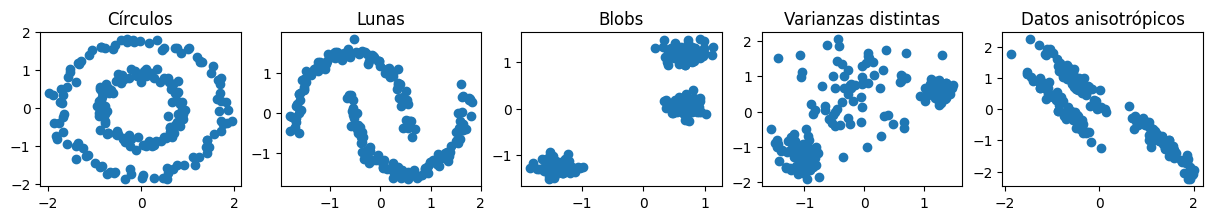

In [19]:
# ============
# Graficamos los datos
# ============
n_rows = 1
n_cols = len(datasets)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2))
axs = axs.flatten()
for (name, data), ax in zip(datasets.items(), axs):
    X, _ = data
    # Normalizamos los datos para que todos estén en la misma escala
    X = StandardScaler().fit_transform(X)
    # TODO: Grafica los datos usando scatter
    # ====== Start of solution =====
    x = X[:,0]
    y = X[:,1]
    ax.scatter(x, y, cmap='nipy_spectral')
    # ====== End of solution =====
    ax.set_title(name)    

### Para los conjuntos de datos anteriores...
Aplica K-means a cada uno de los datasets anteriores. Determina los hiperparámetros (k) que resulten en la mejor asignación según tu criterio para cada grupo.
- ¿En que conjunto/os esperas que k-means realice una solución adecuada? En blobs porque los datos forman grupos claros, separados y compactos. También puede funcionar de forma aceptable en Varianzas distintas y Datos anisotrópicos, aunque no tan bien, porque los grupos tienen formas o dispersiones menos ideales.
- ¿Cuales son las asunciones de k-means? Asume que los clusters son grupos más o menos compactos y separados. También asume que cada grupo puede representarse bien con un centroide.
- ¿Cual de estos conjuntos NO rompe las asunciones de k-means?El conjunto que no rompe las asunciones de K-means es blobs porque sus grupos son compactos, separados y tienen una forma más regular que las demás.

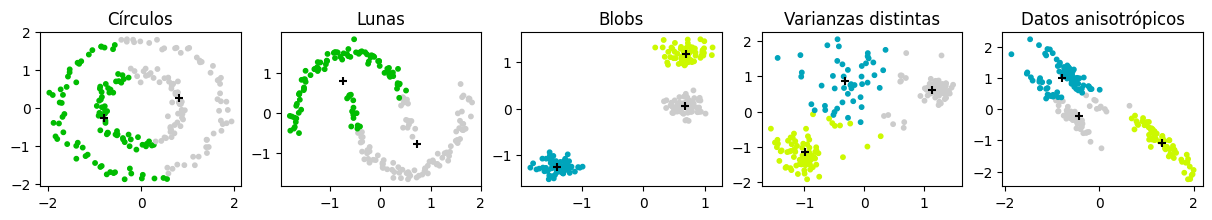

In [23]:
n_rows = 1
n_cols = len(datasets)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2))
axs = axs.flatten()
# TODO: Modifica la cantidad de clusters para cada dataset hasta que encuentres un resultado que te satisfaga
n_clusters = {"Círculos": 2,
              "Lunas": 2,
              "Blobs": 3,
              "Varianzas distintas": 3,
              "Datos anisotrópicos": 3}
for (name, data), n, ax in zip(datasets.items(), n_clusters.values(), axs):
    X, _ = data
    X = StandardScaler().fit_transform(X)
    ax.set_title(name)
    # TODO: Aplica K-means para encontrar los grupos y los centros de cada cluster
    kkmeans = KMeans(n_clusters=n, random_state=random_state)
    kkmeans.fit(X)
    # Después modifica los hiperparámetros en n_clusters según consideres apropiado para cada dataset

    # ====== Start of solution =====

    centers = kkmeans.cluster_centers_
    # ====== End of solution =====
    ax.scatter(X[:, 0], X[:, 1], s=10, c=kkmeans.labels_, vmin=-1)
    ax.scatter(centers[:, 0], centers[:, 1], marker="+", s=30, c='k')

## 2. DBScan
DBScan es otro método de agrupamiento el cual encuentra grupos que funciona a través de densidad local.
En las siguientes celdas, aplica DBScan a cada uno de los datasets anteriores y compara los resultados con los de K-Means. Ajusta los hiperparámetros según tu criterio para lograr un agrupamiento adecuado.

Clusteres en Círculos [-1  0  1  2  3  4  5  6  7  8]
Clusteres en Lunas [-1  0  1  2  3  4  5]
Clusteres en Blobs [-1  0  1  2]
Clusteres en Varianzas distintas [-1  0  1  2  3  4  5]
Clusteres en Datos anisotrópicos [-1  0  1  2]


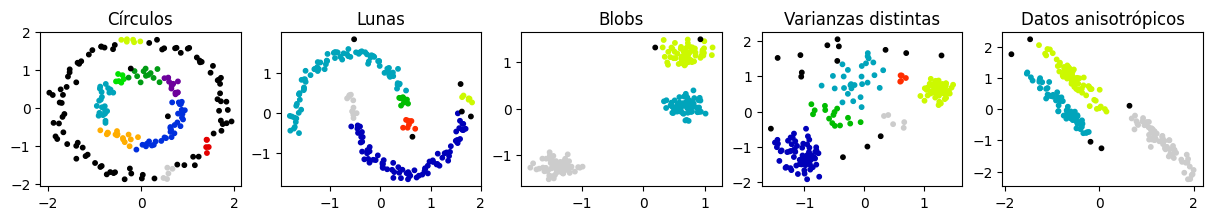

In [33]:
n_rows = 1
n_cols = len(datasets)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2))
axs = axs.flatten()
# TODO: Modifica los hiper parámetros de dbscan hasta encontrar un resultado que te satisfaga
params = {"Círculos": {"eps": 0.2, "min_samples": 5},
          "Lunas": {"eps": 0.2, "min_samples": 4},
          "Blobs": {"eps": 0.20, "min_samples": 7},
          "Varianzas distintas": {"eps": 0.3, "min_samples": 5},
          "Datos anisotrópicos": {"eps": 0.25, "min_samples":4}}
for ((name, data), ax) in zip(datasets.items(), axs):
    X, _ = data
    X = StandardScaler().fit_transform(X)
    ax.set_title(name)
    eps = params[name]['eps']
    min_samples = params[name]['min_samples']
    # TODO: Aplica DBSCAN para encontrar los clusters
    model = DBSCAN(eps=eps, min_samples=min_samples)
    model.fit(X)
    # Después modifica los hiperparámetros en n_clusters según consideres apropiado para cada dataset
    # ====== Start of solution =====
    grupos = model.labels_
    # ====== End of solution =====
    print(f"Clusteres en {name}", np.unique(grupos))
    ax.scatter(X[:, 0], X[:, 1], s=10, c=grupos, vmin=-1)

### TODO: Contesta la siguientes preguntas
- ¿Qué diferencia encuentras entre los clusters encontrados con DBSCAN y los clusters encontrados con K-Means?
Con kmeans los clusters se forman alrededor de centroides, por eso tiende a separar los datos en regiones más redondas o compactas. Con DBSCAN, los clusters se forman según la densidad de los puntos, lo que permite detectar grupos con formas más irregulares.
- ¿Qué metodo clasifica mejor los clusters de Lunas y a qué crees que se deba? El método que clasifica mejor el dataset de Lunas es DBSCAN porque agrupa puntos que están cerca entre sí, siguiendo mejor la forma de espiral del conjunto.
- ¿Qué son los puntos negros encontrados con DBSCAN? Los puntos negros representan los outliers encontrados.
- ¿En qué casos crees que sea recomendable utilizar K-means sobre DBSCAN? Cuando los datos tienen clusters compactos, separados y con forma parecida a círculos o blobs o cuando ya sabemos de antemano cuántos grupos queremos encontrar en el conjunto de datos.
- En base a tu experiencia ¿que desventajas notas para DBScan contra K-means? que depende mucho de elegir bien los hiperparámetros eps y min_samples. Cada movimiento que hacíamos en cualquiera de los 2 hiperparámetros sí se notaba, a ver, tampoco hicimos cambios tan pequeños, pero sí diferencias como pasar de eps de .2 a .25 o .30 y sí se notaba mucho la diferencia
- En base a tu experiencia ¿que ventajas notas para DBScan contra K-means?que puede encontrar clusters con formas irregulares, como lunas o círculos. y que detecta los outliers.
- Si entrenamos DBSCAN y queremos buscar un grupo al que pertenezca un punto nuevo, ¿Existe alguna función de sk-learn que nos permita hacer esto?¿Cómo podríamos predecir el grupo al que pertenece un nuevo datapoint? No existe alguna función de sklearn que nos permita hacer eso. Una forma de hacerlo sería comparar el nuevo punto con los puntos ya agrupados y asignarlo al cluster del punto más cercano.